# Phantom Analysis: Off-Center Rounded-Rectangle Gap, Standard Pipeline, Multiple Downstream Computations

A *phantom* is a feature in a downstream computation that looks like signal but is created entirely by the measurement gap. The framework's central claim is that the geometry of the gap fully determines the geometry of the phantom in every linear computation. The shape of the gap shows up in:

- the **spectrum** (as a Fourier-transform envelope around each true peak),
- **cross-correlation variance** (as a bump in 2D lag space whose footprint is twice the gap dimensions),
- **power-spectrum estimation** (as a smearing kernel $|\hat M|^2$ applied to the true PSD),
- the **two-point correlation function** (as a multiplicative bias factor $A_M(r)/V$ — exactly the Landy-Szalay correction),
- **Wiener inpainting** (as a recoverability lower bound through the framework's principal-angle suppression).

All six of these phantom signatures are computable in advance from the mask $M(x,y)$ alone, or from $M$ and the noise PSD $S_n(k)$ — no observed data required. This notebook fixes one gap geometry — a small rounded rectangle, off-center on a 2D periodic domain — and runs it through six common downstream computations that practitioners actually do, demonstrating each phantom and its framework prediction with Monte Carlo verification.

**Pipeline used throughout.** Observe $y^{(i)} = M\cdot(s + n^{(i)})$, then whiten $\tilde y^{(i)} = W\cdot y^{(i)}$ with $W = 1/\sqrt{S_n}$. This is the standard signal-processing pipeline used in matched filtering, gravitational-wave detection, radar processing, cosmology likelihoods, geomagnetic field analysis, and many other domains.

**Signal model.** For the matched-filter and detection sections (§§2 and 4), we use a *physically motivated two-source signal*: (1) a single coherent plane wave (a "monochromatic source"); and (2) a *wind-driven wave packet* — a superposition of multiple plane waves in approximately the same direction but with different magnitudes, modeling deep-water gravity waves where the dispersion relation $\omega = \sqrt{g|k|}$ makes longer waves travel faster than shorter ones. The packet is dispersive: in time, long components outrun short ones. We work with a single spatial snapshot, but the multi-frequency character of the packet shows up vividly as multiple spectral peaks and multiple stripe families in the analyses. For the random-field sections (§§3, 5, 6, 7), no signal is needed — the phantom emerges from noise interacting with the mask alone.

## §1. Setup

We work on a 2D periodic domain $[-\pi, \pi]^2$ with $N = 128$ samples per side, so the spatial step is $dx = 2\pi/N \approx 0.049$. The mask $M(x,y)$ is the indicator function of the unmasked region: $M = 1$ where we have measurements, $M = 0$ inside the gap. Throughout the notebook, applying the mask to a field means pointwise multiplication: $(Mf)(x) = M(x)\,f(x)$, which zeros out the masked region while leaving the rest unchanged.

### The gap geometry

The gap is a *small rounded rectangle*: a rectangle of half-widths $W \times H$ whose four 90° corners have been replaced with quarter-circle arcs of radius $r$. Equivalently — and how the code constructs it — the gap is the Minkowski sum of an inner "core" rectangle of half-widths $(W-r)\times(H-r)$ with a disk of radius $r$. A point $(x,y)$ is inside the gap if and only if its distance to the inner core rectangle is less than $r$.

We place the gap *well off-center* in the upper-right quadrant, at position $(x_0, y_0) = (1.5,\,1.3)$. The placement matters for §7 (Wiener inpainting) — where the *interior* of the mask is, geometrically, where information is fundamentally lost — but is invisible to the spectral, cross-correlation, PSD, and two-point analyses, because those quantities depend only on $|\hat M|$ or $A_M$, both of which are translation-invariant.

### The colored noise model

The noise has power spectral density (PSD)
$$S_n(k) \;=\; \frac{\sigma_0^2 \, k_c^2}{k_c^2 + |k|^2}$$
with corner wavenumber $k_c = 3$ and overall amplitude $\sigma_0 = 1$. This is a 2D Lorentzian: peaked at $k = 0$, decaying as $1/|k|^2$ at high spatial frequencies. Such noise is *low-spatial-frequency dominated* — it has a real-space correlation length $\sim 1/k_c \approx 0.33$.

### The whitening filter

The standard signal-processing whitening filter is $W(k) = 1/\sqrt{S_n(k)}$. By construction, applying $W$ to the noise yields a field with flat (white) PSD. For our Lorentzian noise, $W$ is small at $k=0$ and grows with $|k|$ — boosting high spatial frequencies to flatten the noise spectrum.

### The figure below

Three panels: the mask, the noise PSD, and the whitening filter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def bold_text(ax, x, y, txt, **kw):
    kw.setdefault('fontweight', 'heavy')
    kw.setdefault('color', 'black')
    t = ax.text(x, y, txt, **kw)
    t.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    return t


def outline_rounded_rect(ax, W, H, r, x0=0, y0=0, color='red', ls='--', lw=1.5):
    bbox = FancyBboxPatch((x0 - W + r, y0 - H + r), 2 * (W - r), 2 * (H - r),
                          boxstyle=f'round,pad=0,rounding_size={r}',
                          fill=False, edgecolor=color, linewidth=lw, linestyle=ls)
    ax.add_patch(bbox)

In [2]:
# ---- 2D domain ----
N = 128
L = 2 * np.pi
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)
y = np.linspace(-L/2, L/2, N, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

# ---- Off-center, small rounded-rectangle gap ----
W_rect, H_rect, r_corner = 1.0, 0.6, 0.20
x_center, y_center = 1.5, 1.3

dx_in = np.maximum(np.abs(X - x_center) - (W_rect - r_corner), 0)
dy_in = np.maximum(np.abs(Y - y_center) - (H_rect - r_corner), 0)
dist_to_inner = np.sqrt(dx_in**2 + dy_in**2)
in_gap = dist_to_inner < r_corner
M = (~in_gap).astype(float)

# ---- Wavenumber grid ----
kx_arr = 2 * np.pi * np.fft.fftfreq(N, d=dx)
ky_arr = 2 * np.pi * np.fft.fftfreq(N, d=dx)
KX, KY = np.meshgrid(kx_arr, ky_arr, indexing='ij')
K_mag = np.sqrt(KX**2 + KY**2)

# ---- Colored noise PSD and whitening filter ----
k_c = 3.0
sigma_0 = 1.0
S_n = sigma_0**2 * k_c**2 / (k_c**2 + K_mag**2)
W_kernel = 1.0 / np.sqrt(S_n)

V = L * L

print(f'Domain: {N}x{N} on [-pi,pi]^2, dx = {dx:.4f}, V = {V:.4f}')
print(f'Mask: rounded rectangle at ({x_center}, {y_center})')
print(f'  W = {W_rect}, H = {H_rect}, corner radius = {r_corner}')
print(f'  Mask area = {(1-M).sum()*dx**2:.4f} '
      f'({100*(1-M).mean():.2f}% of domain)')
print(f'Noise: 2D Lorentzian PSD, k_c = {k_c}, '
      f'real-space correlation length ~ 1/k_c = {1/k_c:.3f}')

Domain: 128x128 on [-pi,pi]^2, dx = 0.0491, V = 39.4784
Mask: rounded rectangle at (1.5, 1.3)
  W = 1.0, H = 0.6, corner radius = 0.2
  Mask area = 2.3036 (5.83% of domain)
Noise: 2D Lorentzian PSD, k_c = 3.0, real-space correlation length ~ 1/k_c = 0.333


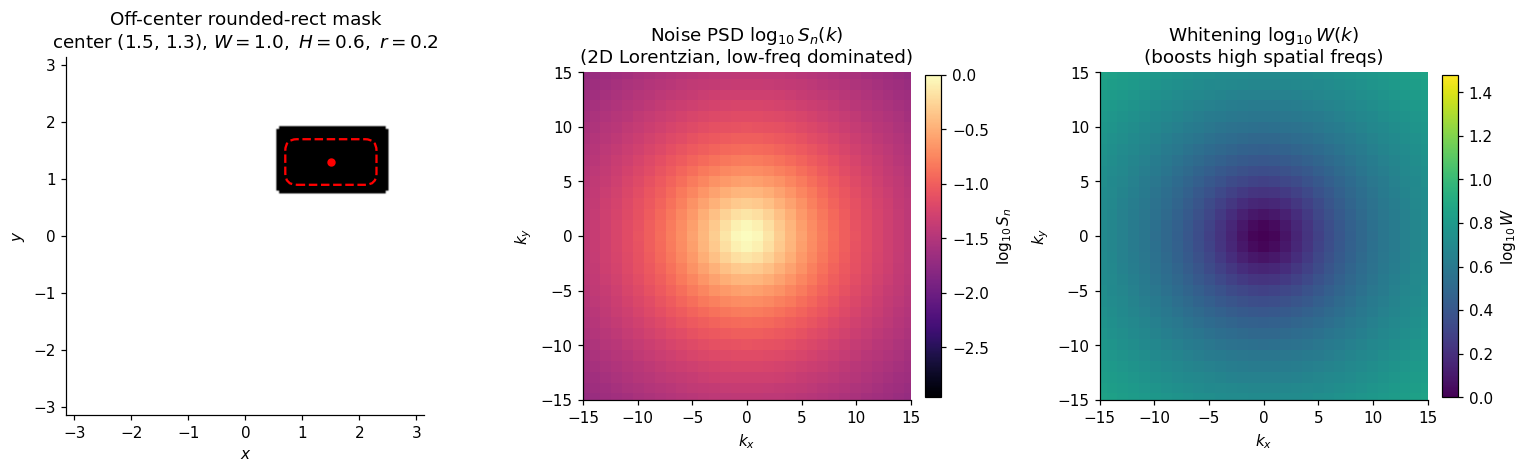

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
ax.imshow(M.T, cmap='gray', origin='lower',
          extent=[-L/2, L/2, -L/2, L/2], vmin=0, vmax=1)
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center)
ax.scatter([x_center], [y_center], s=20, c='red', zorder=5)
ax.set_title(f'Off-center rounded-rect mask\ncenter ({x_center}, {y_center}), '
             f'$W={W_rect},\\ H={H_rect},\\ r={r_corner}$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')

ax = axes[1]
S_n_c = np.fft.fftshift(S_n)
kx_c = np.fft.fftshift(kx_arr)
im = ax.imshow(np.log10(S_n_c.T), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]])
ax.set_title(r'Noise PSD $\log_{10} S_n(k)$' + '\n(2D Lorentzian, low-freq dominated)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label=r'$\log_{10} S_n$')

ax = axes[2]
W_c = np.fft.fftshift(W_kernel)
im = ax.imshow(np.log10(W_c.T), cmap='viridis', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]])
ax.set_title(r'Whitening $\log_{10} W(k)$' + '\n(boosts high spatial freqs)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label=r'$\log_{10} W$')

plt.tight_layout()
plt.show()

## §2. Spectral matched filter (single stream) — coherent source + wind-driven wave packet

### What we're computing

The matched filter is the optimal linear detector for a known signal in additive Gaussian noise: project the data onto a noise-whitened version of the template, then threshold. For coherent plane-wave signals, the template family is $\{\cos(k\cdot x)\}_k$, and the matched-filter scan over $k$ is exactly the Fourier transform of the data. So *spectral analysis is matched filtering*: looking at $|\hat y(k)|^2$ as a function of $k$ is the Neyman-Pearson optimal scan over plane-wave candidates.

### The signal: two physically distinct sources

**Wave 1 — coherent plane wave.** A single sinusoid $\cos(k^{(1)}\cdot x)$ with $k^{(1)} = (8, 0)$. Models a single monochromatic source: a tone at one frequency, no internal structure. Examples: a laser line, a coherent radio carrier, a single planetary tidal mode.

**Wave 2 — wind-driven wave packet.** A superposition of multiple plane waves in approximately the same direction (about $30°$ from the $x$-axis), with different magnitudes and amplitudes following a wind-wave-like spectrum. In a real wind-driven sea, deep-water gravity waves obey the dispersion relation
$$\omega \;=\; \sqrt{g\,|k|},\qquad c = \omega/|k| = \sqrt{g/|k|},$$
so each spectral component travels at its own phase velocity. *Long waves outrun short waves.* Wind-generated swell evolves this way as it propagates: distant storms produce long-wavelength, fast-moving, low-frequency arrivals, followed later by shorter-wavelength, slower, higher-frequency components. The packet *spreads in time* even though no individual mode does.

We use 5 components on the integer FFT grid in approximately the $30°$ direction, with amplitudes from a Gaussian envelope around peak wavenumber $|k_p| = 8$ (qualitatively a Pierson-Moskowitz-like wind-wave spectrum):

| Wave-vector | $\|k\|$ | Angle | Phase velocity $c=\sqrt{g/\|k\|}$ | Amplitude |
|---|---|---|---|---|
| $(3, 2)$ | $\sqrt{13} \approx 3.61$ | $33.7°$ | $\approx 0.527$ | $\approx 0.34$ |
| $(5, 3)$ | $\sqrt{34} \approx 5.83$ | $31.0°$ | $\approx 0.414$ | $\approx 0.77$ |
| $(7, 4)$ | $\sqrt{65} \approx 8.06$ | $29.7°$ | $\approx 0.352$ | $\approx 1.00$ |
| $(9, 5)$ | $\sqrt{106} \approx 10.30$ | $29.1°$ | $\approx 0.312$ | $\approx 0.74$ |
| $(12, 7)$ | $\sqrt{193} \approx 13.89$ | $30.3°$ | $\approx 0.268$ | $\approx 0.14$ |

(taking $g = 1$ in our units). Phase velocities span almost a factor of 2 across the packet — this is what makes wind-driven seas dispersive. Higher-$|k|$ (shorter wavelength) components are slower; lower-$|k|$ (longer wavelength) components are faster. Each component has its own period $T_i = 2\pi/\omega_i = 2\pi/\sqrt{g|k_i|}$, ranging here from about 1.7 (the fastest-oscillating mode) to about 3.3 (the slowest-oscillating mode).

We snap all components to integer-grid wave-vectors so the FFT is clean: any off-grid component would create FFT leakage (a numerical artifact of periodic boundary conditions) that could be visually confused with the gap-induced phantom. On-grid keeps the analysis pure.

### Time evolution vs spatial snapshot

This notebook works with a single *spatial snapshot* of the field at $t = 0$. The dispersion of the packet — components moving at different velocities — does not appear directly in any single figure here, because a single snapshot freezes the time evolution. The figure immediately below visualizes the dispersion separately, by recomputing wave 2 at multiple times and showing how its 1D profile changes.

The phantom analysis (§§2 onwards) does *not* depend on the dispersion: it is a function of the spatial structure of the field at the observation moment, full stop. But the multi-frequency character of the packet shows up vividly: the spectrum has *many* delta locations (12 total: $\pm k^{(1)}$ plus $\pm k^{(2,i)}$ for $i=1\dots 5$), each surrounded by its own rounded-rectangle FT envelope.

### Why the phantom appears

The clean signal has a delta function in $k$-space at every wave-vector that's present in the source. Real-valued cosines give pairs at $\pm k$. So with 1 wave-1 mode + 5 wave-2 modes, we have 6 distinct wave-vectors and thus *12 deltas* in the true spectrum. After masking, $\widehat{Ms}(k) = \hat M * \hat s$, and the convolution with $\hat M$ smears each delta into a copy of $\hat M$ shifted to that delta's location. So the masked spectrum has 12 rounded-rectangle FT envelopes, one centered at each delta.

The envelopes have characteristic widths $\sim 1/W = 1$ along $k_x$ and $\sim 1/H \approx 1.67$ along $k_y$ — set by the gap dimensions, *not* by the source spacings. Adjacent wind-wave components have $k$-distance $\sim \sqrt{5} \approx 2.2$ to $\sqrt{13} \approx 3.6$, larger than the envelope width, so the individual envelopes are partially distinguishable but their sinc-product sidelobes overlap.

After whitening, $\widehat{WMs}(k) = W(k)\cdot\widehat{Ms}(k)$ — pointwise multiplication. Each envelope is reweighted by $W$ at its location. Higher-$|k|$ envelopes (the high-frequency tail of the wind-wave spectrum) get boosted by larger $W$ values; lower-$|k|$ envelopes (the long-wavelength components) get suppressed. So whitening *flattens* the apparent spectral content, partially compensating for the wind-wave spectrum's natural roll-off at high $|k|$.

### Reading the figures

**The dispersion figure (just below the next code cell):** Two panels.
- *Left:* Wave 2 in real space at $t=0$ — the spatial snapshot we use for all subsequent analyses. Shows wave-like ripples in the $30°$ direction with multiple superposed wavelengths.
- *Right:* 1D slice along the $30°$ direction at three times ($t = 0, 2, 4$). The packet *changes shape* over time — peaks and troughs that align at $t=0$ are no longer aligned at $t=4$, because each component has rotated its phase by a different amount. This is dispersion: the same wave system at different times looks different, even though no individual mode is doing anything but rotating its phase.

**The spectrum figure (below that):** Three panels.
- *Left:* the true spectrum — 12 bright deltas, marked with cyan circles. Two on the $k_x$ axis at $\pm 8$ (wave 1); ten arranged along the $30°$ line in $k$-space at the wave-2 wave-vectors.
- *Middle:* masked spectrum — each of the 12 deltas has a rounded-rectangle FT envelope around it. The envelopes are visible but partially overlapping, especially the cluster of 5 wind-wave envelopes along the $30°$ direction.
- *Right:* masked + whitened. Same structure with high-$|k|$ envelopes brighter relative to low-$|k|$ ones.

### Practical implication

The framework's prediction $|\widehat{WMs}| = W(k)\cdot|\widehat{Ms}|$ is an *operator identity* — exact regardless of the signal complexity. It still holds to floating-point precision for our 6-mode packet, just as it did for a single sine wave. This means the framework's calibration (the predicted phantom shape around each mode) extends *linearly* across all modes: each component contributes its own envelope, and the total phantom is the sum.

For wind-driven oceanographic, atmospheric, or seismic data, this is exactly the framework you need: each spectral component of the source spectrum gets its own gap-induced phantom envelope, and the predicted total phantom is *known in advance from the gap shape and the source spectrum* — both of which are usually known.

In [4]:
# ---- Two-source signal: coherent wave + wind-driven wave packet ----

# Wave 1: single coherent plane wave
k1_x, k1_y = 8.0, 0.0
wave1 = np.cos(k1_x * X + k1_y * Y)

# Wave 2: WIND-DRIVEN WAVE PACKET (5 components on the integer FFT grid,
# all in approximately the 30 deg direction, amplitudes from a Gaussian
# envelope around peak |k| = k_peak — qualitatively Pierson-Moskowitz)
wave2_vectors = [(3, 2), (5, 3), (7, 4), (9, 5), (12, 7)]
k_peak = 8.0
sigma_k = 3.0

wave2_amplitudes = []
wave2_magnitudes = []
for (kx_i, ky_i) in wave2_vectors:
    k_mag = np.sqrt(kx_i**2 + ky_i**2)
    amp = np.exp(-(k_mag - k_peak)**2 / (2 * sigma_k**2))
    wave2_amplitudes.append(amp)
    wave2_magnitudes.append(k_mag)

# Build wave 2 as the spatial snapshot at t=0
wave2 = np.zeros_like(X)
for (kx_i, ky_i), amp in zip(wave2_vectors, wave2_amplitudes):
    wave2 += amp * np.cos(kx_i * X + ky_i * Y)

# Combined signal (used throughout)
signal = wave1 + wave2

# Print summary table
print('Signal structure:')
print(f'  Wave 1: single coherent plane wave at k = ({k1_x:.1f}, {k1_y:.1f}), '
      f'|k| = {np.hypot(k1_x, k1_y):.2f}')
print(f'  Wave 2: wind-driven wave packet ({len(wave2_vectors)} components):')
print(f'    {"k-vec":>8} {"|k|":>6} {"angle":>7} {"omega":>7} '
      f'{"c=sqrt(1/|k|)":>14} {"amplitude":>10}')
g_water = 1.0
for (kx_i, ky_i), amp, k_mag in zip(wave2_vectors, wave2_amplitudes,
                                       wave2_magnitudes):
    angle = np.rad2deg(np.arctan2(ky_i, kx_i))
    omega_i = np.sqrt(g_water * k_mag)
    c_i = omega_i / k_mag
    print(f'    ({kx_i:2d},{ky_i:2d})  {k_mag:5.2f}  {angle:5.2f}°  '
          f'{omega_i:5.3f}  {c_i:11.3f}      {amp:6.3f}')

c_min = 1.0 / np.sqrt(max(wave2_magnitudes))
c_max = 1.0 / np.sqrt(min(wave2_magnitudes))
print(f'\n  Phase-velocity spread: {c_min:.3f} to {c_max:.3f}'
      f' (factor of {c_max/c_min:.2f}x — packet is dispersive)')

# ---- Pipeline outputs ----
spec_clean = np.abs(np.fft.fft2(signal))
spec_masked = np.abs(np.fft.fft2(M * signal))
WMs = np.real(np.fft.ifft2(np.fft.fft2(M * signal) * W_kernel))
spec_whitened_masked = np.abs(np.fft.fft2(WMs))

# Framework prediction (still exact for arbitrary multi-component signals)
spec_predicted = W_kernel * spec_masked
significant = spec_masked > spec_masked.max() * 0.01
abs_err = np.abs(spec_whitened_masked[significant] - spec_predicted[significant])
mean_rel_err = np.mean(abs_err / spec_predicted[significant])
print(f'\nFramework verification (still exact for multi-component signal):')
print(f'  Mean relative error: {mean_rel_err:.3e}')
print(f'  -> The identity |FT(WMs)| = W(k)*|FT(Ms)| is operator-level,')
print(f'     independent of how many sources are present.')

Signal structure:
  Wave 1: single coherent plane wave at k = (8.0, 0.0), |k| = 8.00
  Wave 2: wind-driven wave packet (5 components):
       k-vec    |k|   angle   omega  c=sqrt(1/|k|)  amplitude
    ( 3, 2)   3.61  33.69°  1.899        0.527       0.342
    ( 5, 3)   5.83  30.96°  2.415        0.414       0.770
    ( 7, 4)   8.06  29.74°  2.839        0.352       1.000
    ( 9, 5)  10.30  29.05°  3.209        0.312       0.746
    (12, 7)  13.89  30.26°  3.727        0.268       0.145

  Phase-velocity spread: 0.268 to 0.527 (factor of 1.96x — packet is dispersive)

Framework verification (still exact for multi-component signal):
  Mean relative error: 3.717e-16
  -> The identity |FT(WMs)| = W(k)*|FT(Ms)| is operator-level,
     independent of how many sources are present.


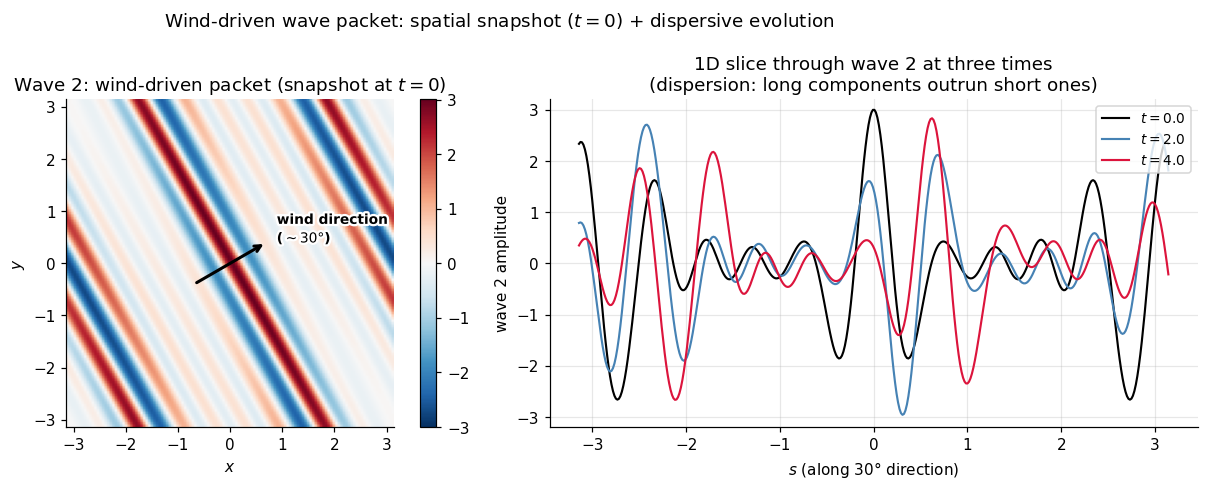

In [5]:
# ---- Visualize wave 2's dispersive evolution over time ----
# Each component travels at its own phase velocity; we show the resulting
# packet shape at three different times.

times_to_show = [0.0, 2.0, 4.0]
ang_30 = np.deg2rad(30)
cos30, sin30 = np.cos(ang_30), np.sin(ang_30)
s_axis = np.linspace(-L/2, L/2, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: 2D snapshot of wave 2 at t=0
ax = axes[0]
vmax_wv = np.abs(wave2).max()
im = ax.imshow(wave2.T, cmap='RdBu_r', vmin=-vmax_wv, vmax=vmax_wv,
               origin='lower', extent=[-L/2, L/2, -L/2, L/2])
# Indicate the wind / propagation direction
arrow_len = 0.8
ax.annotate('', xy=(arrow_len * cos30, arrow_len * sin30),
            xytext=(-arrow_len * cos30, -arrow_len * sin30),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
bold_text(ax, arrow_len * cos30 + 0.2, arrow_len * sin30,
          'wind direction\n($\\sim 30°$)', fontsize=9)
ax.set_title('Wave 2: wind-driven packet (snapshot at $t=0$)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

# Right: 1D slice along 30 deg direction, at three times
ax = axes[1]
slice_colors = ['black', 'steelblue', 'crimson']
for color, t_val in zip(slice_colors, times_to_show):
    wave2_slice = np.zeros_like(s_axis)
    for (kx_i, ky_i), amp in zip(wave2_vectors, wave2_amplitudes):
        k_mag = np.sqrt(kx_i**2 + ky_i**2)
        omega_i = np.sqrt(g_water * k_mag)
        # Position along 30 deg direction: x = s*cos30, y = s*sin30
        # Wave at this point: cos(kx_i*x + ky_i*y - omega_i*t)
        wave2_slice += amp * np.cos(
            (kx_i * cos30 + ky_i * sin30) * s_axis - omega_i * t_val)
    ax.plot(s_axis, wave2_slice, color=color, linewidth=1.4,
            label=f'$t = {t_val:.1f}$')
ax.set_xlabel('$s$ (along $30°$ direction)')
ax.set_ylabel('wave 2 amplitude')
ax.set_title('1D slice through wave 2 at three times\n'
             '(dispersion: long components outrun short ones)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(-3.2, 3.2)

plt.suptitle('Wind-driven wave packet: spatial snapshot ($t=0$) + dispersive evolution',
             fontsize=12)
plt.tight_layout()
plt.show()

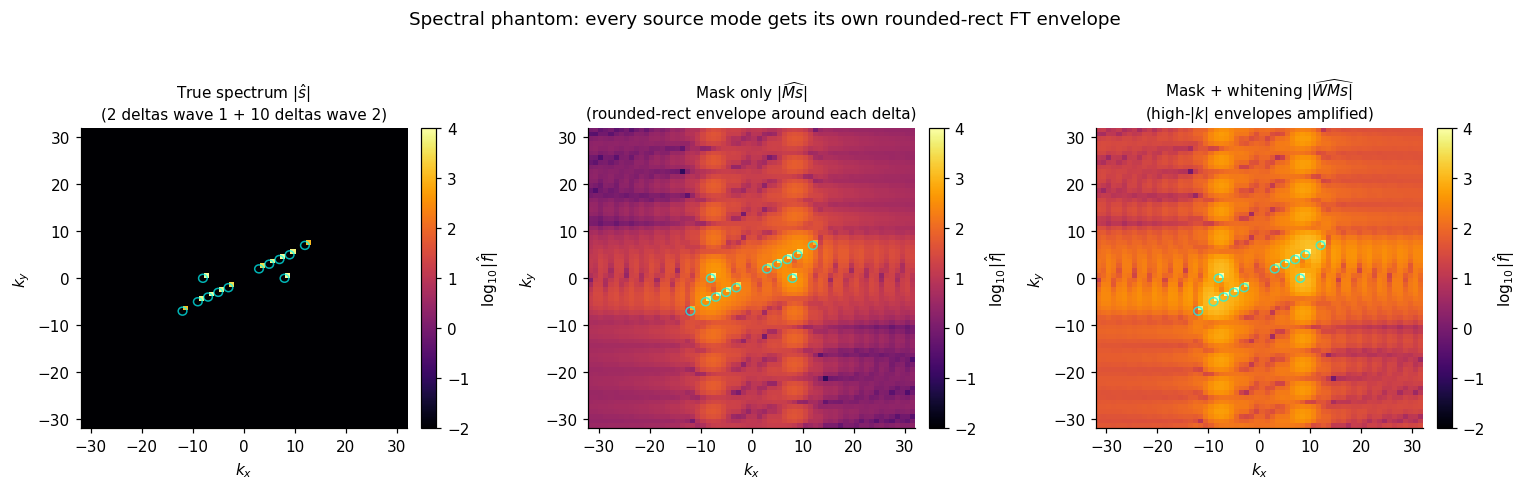

In [6]:
# ---- Spectrum figure: 3 panels with all 12 delta locations marked ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

zoom_pix = N // 4
center_idx = N // 2
zoom_slice = slice(center_idx - zoom_pix, center_idx + zoom_pix)
k_zoom_max = (kx_arr[1] - kx_arr[0]) * zoom_pix
k_zoom_extent = [-k_zoom_max, k_zoom_max, -k_zoom_max, k_zoom_max]

# All 12 delta locations
all_delta_locs = [(k1_x, k1_y), (-k1_x, -k1_y)]
for (kx_i, ky_i) in wave2_vectors:
    all_delta_locs.append((kx_i, ky_i))
    all_delta_locs.append((-kx_i, -ky_i))


def plot_spec(ax, S, title, vmin=-2, vmax=4):
    Ss = np.fft.fftshift(S)
    im = ax.imshow(np.log10(Ss[zoom_slice, zoom_slice] + 1e-3).T,
                   cmap='inferno', origin='lower', extent=k_zoom_extent,
                   vmin=vmin, vmax=vmax, aspect='auto')
    for (kx_d, ky_d) in all_delta_locs:
        ax.add_patch(plt.Circle((kx_d, ky_d), 0.85, fill=False,
                                 edgecolor='cyan', linewidth=1.0,
                                 alpha=0.7))
    ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label=r'$\log_{10}|\hat{f}|$')


plot_spec(axes[0], spec_clean,
          r'True spectrum $|\hat{s}|$' + '\n(2 deltas wave 1 + 10 deltas wave 2)')
plot_spec(axes[1], spec_masked,
          r'Mask only $|\widehat{Ms}|$' + '\n(rounded-rect envelope around each delta)')
plot_spec(axes[2], spec_whitened_masked,
          r'Mask + whitening $|\widehat{WMs}|$' + '\n(high-$|k|$ envelopes amplified)')

plt.suptitle('Spectral phantom: every source mode gets its own rounded-rect FT envelope',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## §3. Cross-correlation (two streams, common mask)

### What we're computing

Two independent measurement streams, each observing a field through the same mask, with independent noise: $y^{(i)}(x) = M(x)\cdot(s(x) + n^{(i)}(x))$ for $i = 1, 2$. We whiten each, and form the cross-correlation
$$\hat C(\Delta) \;=\; \int \tilde y^{(1)}(x)\,\tilde y^{(2)}(x+\Delta)\,d^2x.$$

### Why the phantom appears under the null

Under the null (independent noise streams, no signal), $\mathbb{E}[\hat C(\Delta)] = 0$ exactly — no first-moment phantom. But the *variance* of $\hat C$ across realizations has 2D structure inherited from the mask.

At lag $\Delta$, the integrand is non-zero only where both $x$ and $x+\Delta$ are unmasked. The 2D area of this overlap is the mask autocorrelation
$$A_M(\Delta) \;=\; \int M(x)\,M(x+\Delta)\,d^2x.$$
For Gaussian noise, $\mathrm{Var}[\hat C(\Delta)] \propto A_M(\Delta)$ — proportional to the overlap area at each lag.

For our rounded-rectangle gap, $A_M$ has a broad bump centered at $\Delta = 0$, with footprint $2W \times 2H$ and rounded corners inherited from the gap shape.

### Translation invariance

The variance bump is centered at $\Delta = 0$ regardless of the gap's spatial position — $A_M$ is exactly translation-invariant. Only gap *shape* (not position) sets the cross-correlation phantom.

### Reading the figure

- **Left:** empirical variance map from 1500 null Monte Carlo realizations. Bright bump at center with rounded-rectangle footprint; white dotted outline marks predicted boundary.
- **Middle / Right:** 1D slices through long ($\Delta_y=0$) and short ($\Delta_x=0$) axes. Vertical blue lines mark $|\Delta_x|=2W$ and $|\Delta_y|=2H$.

### Practical implication

Under the null, applying a uniform threshold across all lags gives a non-uniform false-alarm rate — preferential detections cluster at small lags. To get uniform false-alarm, threshold against $\sigma(\Delta) = \sqrt{\mathrm{Var}[\hat C(\Delta)]}$, computable in advance from the mask. Used in §4.

In [7]:
def generate_colored_noise():
    n_white = np.random.standard_normal((N, N))
    Z = np.fft.fft2(n_white)
    return np.real(np.fft.ifft2(Z * np.sqrt(S_n)))


def whiten(field):
    F = np.fft.fft2(field)
    return np.real(np.fft.ifft2(F * W_kernel))


# Monte Carlo: null distribution of Chat
n_real = 1500
sum_C = np.zeros((N, N))
sum_C_sq = np.zeros((N, N))

print(f'Running {n_real} null realizations through the full pipeline...')
for i in range(n_real):
    n1 = generate_colored_noise()
    n2 = generate_colored_noise()
    y1_w = whiten(M * n1)
    y2_w = whiten(M * n2)
    Y1 = np.fft.fft2(y1_w)
    Y2 = np.fft.fft2(y2_w)
    C = np.real(np.fft.ifft2(np.conj(Y1) * Y2)) * dx**2
    sum_C += C
    sum_C_sq += C**2
    if (i + 1) % 500 == 0:
        print(f'  realization {i+1}/{n_real}')

mean_C = sum_C / n_real
var_C = sum_C_sq / n_real - mean_C**2

print()
print(f'Variance map:')
print(f'  peak    = {var_C.max():.4f}')
print(f'  plateau = {var_C[N//2, N//2]:.4f}')
print(f'  ratio   = {var_C.max() / var_C[N//2, N//2]:.3f}')

Running 1500 null realizations through the full pipeline...


  realization 500/1500


  realization 1000/1500


  realization 1500/1500

Variance map:
  peak    = 0.1000
  plateau = 0.0824
  ratio   = 1.213


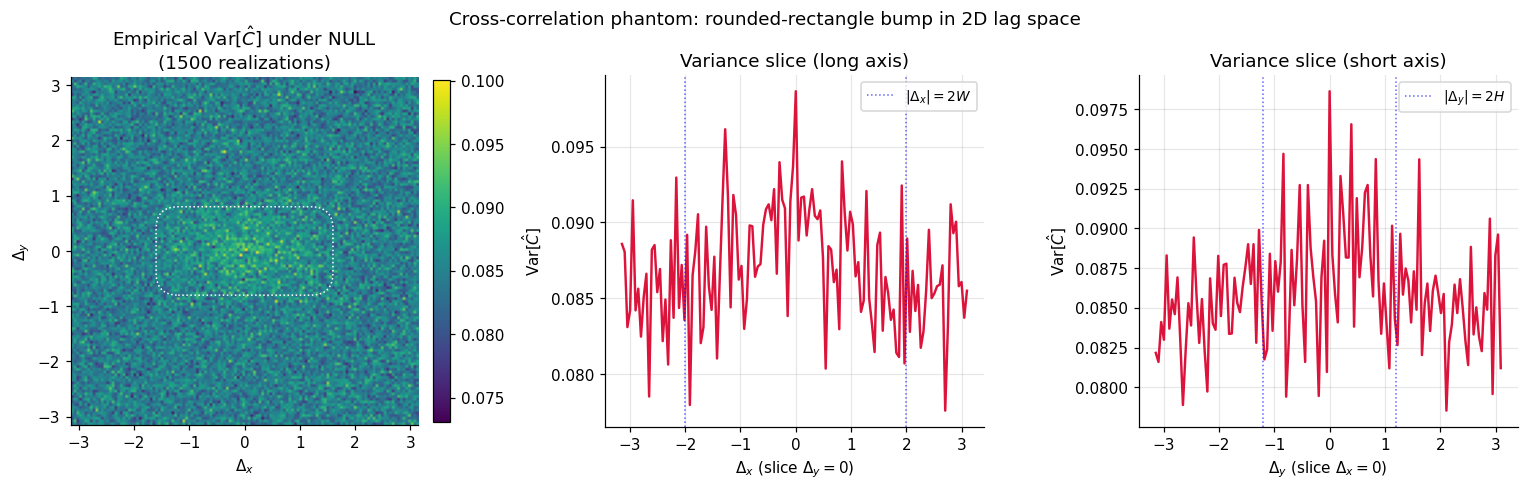

In [8]:
var_C_c = np.fft.fftshift(var_C)
lag_axis = np.fft.fftshift(np.fft.fftfreq(N, d=1) * L)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
im = ax.imshow(var_C_c.T, cmap='viridis', origin='lower',
               extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, 2 * W_rect, 2 * H_rect, 2 * r_corner, 0, 0,
                     color='white', ls=':', lw=1.0)
ax.set_title(r'Empirical Var[$\hat{C}$] under NULL' + f'\n({n_real} realizations)')
ax.set_xlabel(r'$\Delta_x$'); ax.set_ylabel(r'$\Delta_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1]
center = N // 2
ax.plot(lag_axis, var_C_c[:, center], color='crimson', linewidth=1.6)
ax.axvline(2 * W_rect, color='blue', linestyle=':', alpha=0.6,
           linewidth=1, label=r'$|\Delta_x|=2W$')
ax.axvline(-2 * W_rect, color='blue', linestyle=':', alpha=0.6, linewidth=1)
ax.set_xlabel(r'$\Delta_x$ (slice $\Delta_y=0$)')
ax.set_ylabel(r'Var[$\hat{C}$]')
ax.set_title('Variance slice (long axis)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(lag_axis, var_C_c[center, :], color='crimson', linewidth=1.6)
ax.axvline(2 * H_rect, color='blue', linestyle=':', alpha=0.6,
           linewidth=1, label=r'$|\Delta_y|=2H$')
ax.axvline(-2 * H_rect, color='blue', linestyle=':', alpha=0.6, linewidth=1)
ax.set_xlabel(r'$\Delta_y$ (slice $\Delta_x=0$)')
ax.set_ylabel(r'Var[$\hat{C}$]')
ax.set_title('Variance slice (short axis)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Cross-correlation phantom: rounded-rectangle bump in 2D lag space',
             fontsize=12)
plt.tight_layout()
plt.show()

## §4. Real-signal detection through the full pipeline — coherent + wind-wave packet

### What we're computing

The same two-source signal from §2 (single coherent plane wave at $k^{(1)} = (8,0)$ + 5-component wind-wave packet at $\sim 30°$) is added to *both* streams. The full pipeline runs as before — observe through gap, whiten, cross-correlate. We compare $\hat C(\Delta)$ for signal-only and signal+noise against the null phantom band $\pm 3\sigma(\Delta)$ from §3.

### What "phantom band" means precisely

The phantom band is the gray $\pm 3\sigma(\Delta_x)$ envelope along $\Delta_y = 0$, with $\sigma(\Delta) = \sqrt{\mathrm{Var}[\hat C(\Delta)]\,|\,\text{null}}$ from §3. It's a *non-uniform* envelope — wider where the variance bump is bigger (small $\Delta$), narrower where the variance is at its plateau (large $\Delta$). It's a *second-moment* phantom: structured null variance, not a non-zero null mean. There's no first-moment phantom in this cross-correlation case.

### What a multi-component cross-correlation looks like

For signal $s = w_1 + w_2$ with $w_2 = \sum_i a_i \cos(k^{(2,i)}\!\cdot\! x)$, the self-cross-correlation expands as
$$\hat C \;\propto\; (w_1 \star w_1) + 2(w_1 \star w_2) + (w_2 \star w_2),$$
and within $w_2 \star w_2 = \sum_{i,j} a_i a_j \cos(k^{(2,i)}\!\cdot\! x)\star\cos(k^{(2,j)}\!\cdot\! x)$, every $i,j$ pair contributes either a self-term ($i=j$, frequency $k^{(2,i)}$) or a cross-term ($i\neq j$, frequencies $k^{(2,i)}\pm k^{(2,j)}$). With wave 1 + 5 wave-2 modes, you get 1 wave-1 self-stripe + 5 wave-2 self-stripes + 10 wave-2 cross-stripes + 10 wave-1×wave-2 cross-stripes — a total of **26 distinct stripe families** in the cross-correlation map. Heuristically: each mode pair contributes a stripe family at the sum and difference of their wave-vectors.

In practice many of these stripes have small amplitude (high-$|k|$ wave-2 modes have small $a_i$) and merge visually. What you see in the figure is dominated by:
1. **Wave 1's self-stripes** — vertical, frequency 8, large amplitude.
2. **Wave 2's strongest self-stripes** — tilted at $\sim 30°$, multiple periods (the wind-wave wavelengths), forming the moiré-like wind-wave pattern.
3. **Their interference** — irregular modulation across the field.

The cross-correlation map is a *direct multi-source imager*: the angular distribution of stripe families tells you the wind-wave directional spread; the period distribution tells you the wave-number spectrum; wave 1 stands out as a distinct narrow direction.

### Reading the 1D slice

The slice through $\Delta_y = 0$ catches every stripe family's projection onto the $\Delta_x$ axis. With many components present, the slice shows a *broadband* multi-frequency oscillation — a sum of cosines at various frequencies (8, 12, 7, 9, 5, 3 from the self-terms; their pairwise sums and differences from cross-terms; wave-1 ⊗ wave-2 contributions at $8\pm$ each wave-2 $k_x$). This is what wind-driven seas look like in cross-correlation: not a clean single-frequency oscillation but a *spectrum* superposed across many frequencies, with the long-wavelength components dominating.

### Shape discrimination

Each source mode contributes a delta-like peak at its own wave-vector in the 2D Fourier transform of $\hat C(\Delta)$. The phantom variance bump lives at low spatial frequencies in lag-Fourier space. So:
- **Bandpass at $\pm k^{(1)}$:** isolates wave 1.
- **Bandpass at any $\pm k^{(2,i)}$:** isolates that wind-wave component.
- **Bandpass at low frequencies:** isolates the phantom.

The framework predicts the location of every signal mode in the cross-correlation Fourier domain *and* the location of the phantom — a complete spectral separation. Pipelines that exploit this Fourier-localization are robust well below the "punches through band" threshold.

### Reading the figure

- **Left:** signal-only cross-correlation. Vertical wave-1 stripes are visible; the wind-wave pattern at $\sim 30°$ shows multiple superposed wavelengths; their interference creates a complex moiré.
- **Middle:** signal + noise (one realization). Same structure with noise.
- **Right:** 1D slice through $\Delta_y = 0$, with the phantom band. The signal's broadband oscillation punches through dramatically; the multi-frequency content is visible as irregular oscillation amplitude.

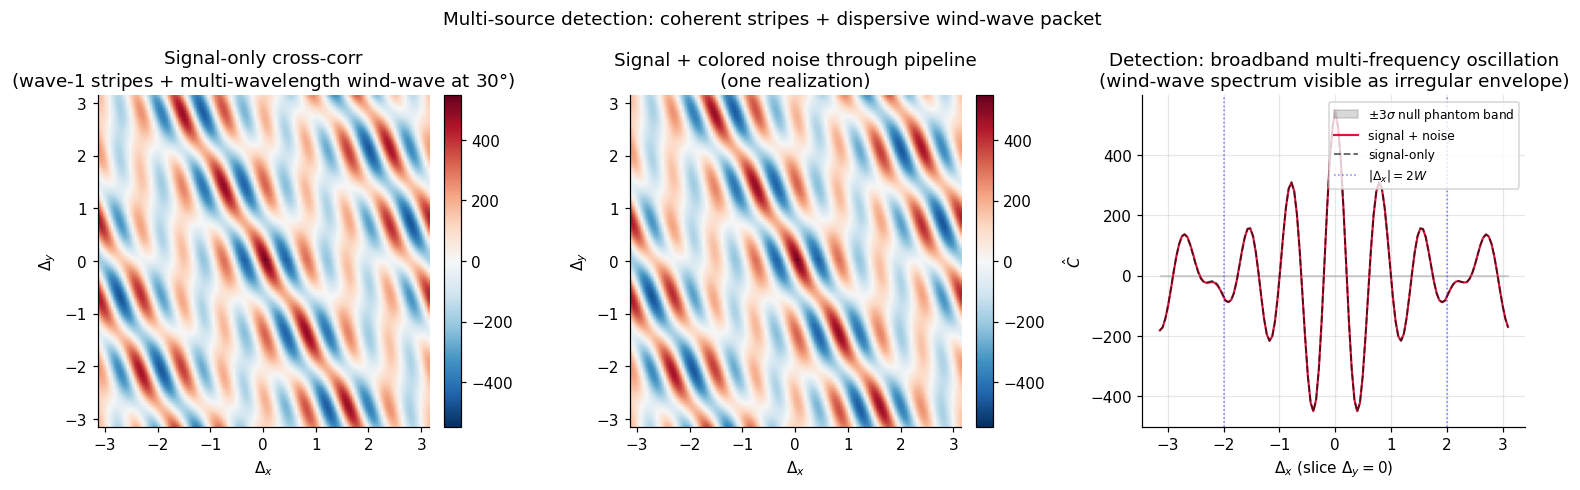

In [9]:
# Signal-only through pipeline
y1_so = whiten(M * signal)
y2_so = whiten(M * signal)
C_signal_only = np.real(np.fft.ifft2(
    np.conj(np.fft.fft2(y1_so)) * np.fft.fft2(y2_so))) * dx**2

# Signal + colored noise
n1_sig = generate_colored_noise()
n2_sig = generate_colored_noise()
y1_sig = whiten(M * (signal + n1_sig))
y2_sig = whiten(M * (signal + n2_sig))
C_with_signal = np.real(np.fft.ifft2(
    np.conj(np.fft.fft2(y1_sig)) * np.fft.fft2(y2_sig))) * dx**2

C_signal_only_c = np.fft.fftshift(C_signal_only)
C_with_signal_c = np.fft.fftshift(C_with_signal)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
vmax = np.abs(C_signal_only_c).max()
im = ax.imshow(C_signal_only_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title('Signal-only cross-corr\n'
             '(wave-1 stripes + multi-wavelength wind-wave at $30°$)')
ax.set_xlabel(r'$\Delta_x$'); ax.set_ylabel(r'$\Delta_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1]
vmax2 = np.abs(C_with_signal_c).max()
im = ax.imshow(C_with_signal_c.T, cmap='RdBu_r', vmin=-vmax2, vmax=vmax2,
               origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title('Signal + colored noise through pipeline\n(one realization)')
ax.set_xlabel(r'$\Delta_x$'); ax.set_ylabel(r'$\Delta_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[2]
sigma_band = np.sqrt(var_C_c[:, center])
ax.fill_between(lag_axis, -3 * sigma_band, 3 * sigma_band, color='gray',
                alpha=0.30, label=r'$\pm 3\sigma$ null phantom band')
ax.plot(lag_axis, C_with_signal_c[:, center], color='crimson', linewidth=1.4,
        label='signal + noise')
ax.plot(lag_axis, C_signal_only_c[:, center], color='black', linewidth=1.2,
        linestyle='--', alpha=0.6, label='signal-only')
ax.axvline(2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1,
           label=r'$|\Delta_x|=2W$')
ax.axvline(-2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlabel(r'$\Delta_x$ (slice $\Delta_y=0$)')
ax.set_ylabel(r'$\hat{C}$')
ax.set_title('Detection: broadband multi-frequency oscillation\n'
             '(wind-wave spectrum visible as irregular envelope)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Multi-source detection: coherent stripes + dispersive wind-wave packet',
             fontsize=12)
plt.tight_layout()
plt.show()

## §5. Power spectrum (PSD) estimation

### What we're computing

The PSD of a stationary noise field is $S_n(k) = \mathbb{E}[|\hat n(k)|^2]/N^2$. The standard estimator is the periodogram, averaged over realizations. We examine how the periodogram behaves when the field is observed only through the mask $M$.

### Why the phantom appears

For Gaussian noise:
$$\mathbb{E}\bigl[|\widehat{Mn}(k)|^2\bigr] \;=\; \frac{1}{N^d}\bigl(|\hat M|^2 * S_n\bigr)(k)$$
— true PSD convolved with $|\hat M|^2$. Mask-induced spectral leakage: power at one frequency leaks into nearby frequencies in proportion to $|\hat M(k - k')|^2$. The kernel $|\hat M|^2$ has width $\sim 1/W$ along $k_x$, $\sim 1/H$ along $k_y$ — the gap dimensions set the spectral resolution.

### Connection to pseudo-$C_\ell$

This is exactly the *mode-mixing matrix* used in CMB and large-scale structure analysis on a cut sky. The pseudo-$C_\ell$ deconvolution inverts this convolution to recover the true $C_\ell$.

### Reading the figure

Three 2D panels (true PSD, predicted masked PSD, empirical) plus a 1D radial slice. For our small gap, the smearing is mild — visible as slight peak attenuation and wing contamination.

In [10]:
M_fft_sq = np.abs(np.fft.fft2(M))**2

psd_predicted = np.real(np.fft.ifft2(
    np.fft.fft2(M_fft_sq) * np.fft.fft2(S_n))) / N**2

n_real_psd = 300
sum_psd_masked = np.zeros((N, N))
for i in range(n_real_psd):
    n_real_sample = generate_colored_noise()
    sum_psd_masked += np.abs(np.fft.fft2(M * n_real_sample))**2
psd_empirical = sum_psd_masked / n_real_psd

significant_psd = S_n > S_n.max() * 0.05
mean_rel_err_psd = np.mean(np.abs(psd_empirical[significant_psd] -
                                     psd_predicted[significant_psd]) /
                              psd_predicted[significant_psd])
print(f'Empirical / predicted comparison:')
print(f'  Mean relative error: {mean_rel_err_psd:.3e}')

Empirical / predicted comparison:
  Mean relative error: 4.345e-02


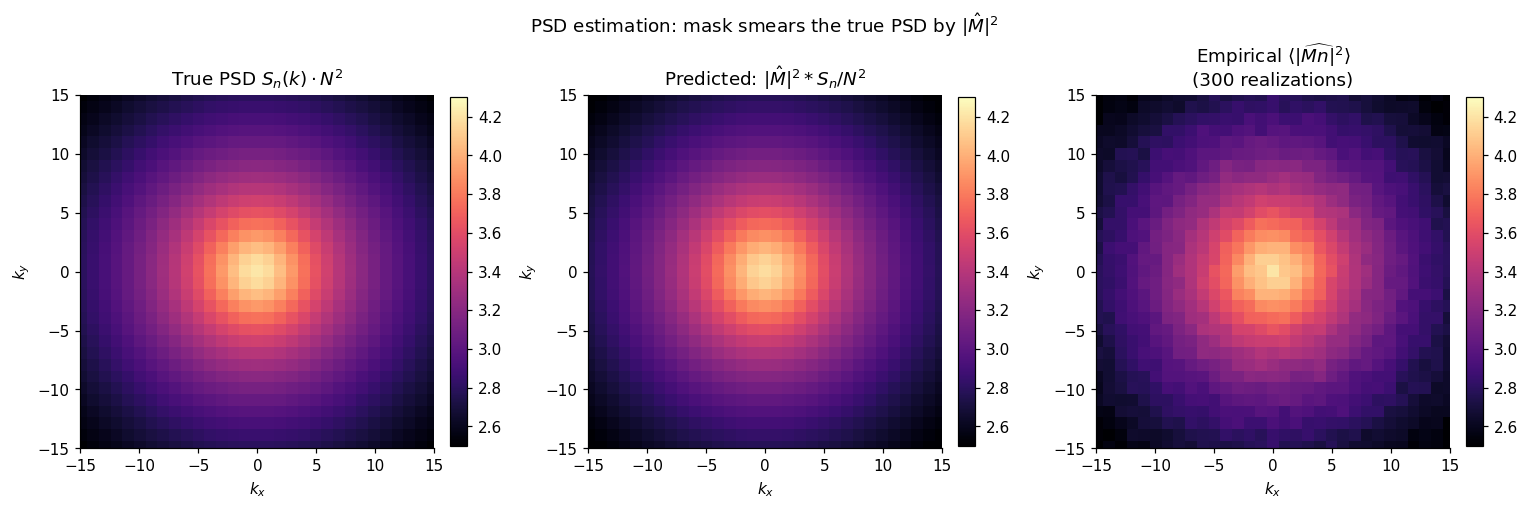

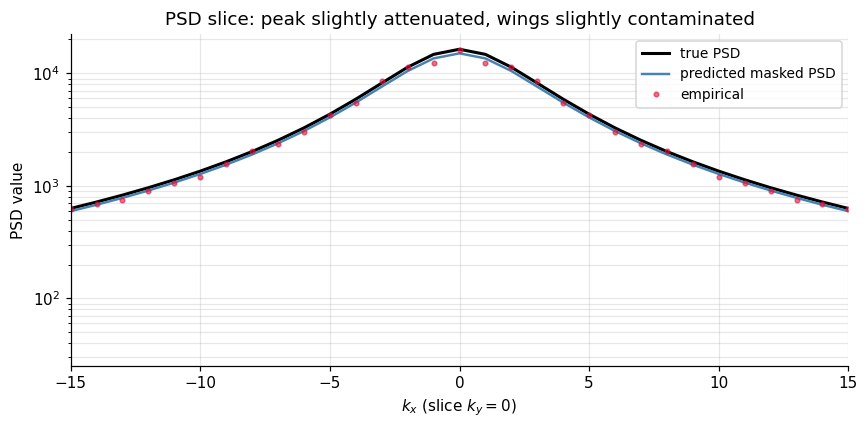

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

S_n_c = np.fft.fftshift(S_n)
psd_pred_c = np.fft.fftshift(psd_predicted)
psd_emp_c = np.fft.fftshift(psd_empirical)

vmin_psd, vmax_psd = 2.5, 4.3

ax = axes[0]
im = ax.imshow(np.log10(S_n_c.T * N**2), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]],
               vmin=vmin_psd, vmax=vmax_psd)
ax.set_title(r'True PSD $S_n(k)\cdot N^2$')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1]
im = ax.imshow(np.log10(psd_pred_c.T), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]],
               vmin=vmin_psd, vmax=vmax_psd)
ax.set_title('Predicted: $|\\hat M|^2 * S_n / N^2$')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[2]
im = ax.imshow(np.log10(psd_emp_c.T), cmap='magma', origin='lower',
               extent=[kx_c[0], kx_c[-1], kx_c[0], kx_c[-1]],
               vmin=vmin_psd, vmax=vmax_psd)
ax.set_title(f'Empirical $\\langle|\\widehat{{Mn}}|^2\\rangle$\n'
             f'({n_real_psd} realizations)')
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

plt.suptitle('PSD estimation: mask smears the true PSD by $|\\hat M|^2$',
             fontsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ky_zero_idx = N // 2
kx_centered = np.fft.fftshift(kx_arr)
ax.semilogy(kx_centered, S_n_c[:, ky_zero_idx] * N**2,
            color='black', linewidth=2, label=r'true PSD')
ax.semilogy(kx_centered, psd_pred_c[:, ky_zero_idx],
            color='steelblue', linewidth=1.6, label='predicted masked PSD')
ax.semilogy(kx_centered, psd_emp_c[:, ky_zero_idx],
            'o', color='crimson', markersize=3, alpha=0.6, label='empirical')
ax.set_xlim(-15, 15)
ax.set_xlabel('$k_x$ (slice $k_y = 0$)')
ax.set_ylabel('PSD value')
ax.set_title('PSD slice: peak slightly attenuated, wings slightly contaminated')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## §6. Two-point correlation function (autocorrelation)

### What we're computing

The two-point function $\xi(r) = \mathbb{E}[f(x)f(x+r)] = \mathcal{F}^{-1}[S_n](r)$ — real-space twin of §5. The standard raw estimator from masked data:
$$\hat\xi_{\rm raw}(r) \;=\; \frac{1}{V}\int M(x)\,f(x)\,M(x+r)\,f(x+r)\,d^2x.$$

### Why the phantom appears

$\mathbb{E}[\hat\xi_{\rm raw}(r)] = (A_M(r)/V)\,\xi(r)$ — multiplicatively biased by the geometric factor $A_M(r)/V$ (fraction of pairs at separation $r$ where both endpoints are unmasked).

### The Landy-Szalay correction

Divide by $A_M(r)/V$ to get $\hat\xi_{\rm corr}$, which is unbiased. In galaxy survey analysis this is exactly the **Landy-Szalay estimator** $(DD - 2DR + RR)/RR$ where $RR$ in the random-catalog limit is exactly $A_M(r)$.

### Reading the figure

Top: 2D true, raw, corrected. Bottom: 1D radial profile, geometric factor $A_M/V$, empirical bias verification.

In [12]:
A_M = np.real(np.fft.ifft2(np.abs(np.fft.fft2(M))**2)) * dx**2
A_M_normalized = A_M / V

xi_true = np.real(np.fft.ifft2(S_n))

n_real_xi = 200
sum_xi_raw = np.zeros((N, N))

print(f'Running {n_real_xi} realizations for xi estimation...')
for i in range(n_real_xi):
    n_sample = generate_colored_noise()
    Mn = M * n_sample
    xi_raw = np.real(np.fft.ifft2(np.abs(np.fft.fft2(Mn))**2)) / N**2
    sum_xi_raw += xi_raw

mean_xi_raw = sum_xi_raw / n_real_xi

mask_safe = A_M_normalized > 0.01
mean_xi_corrected = np.where(mask_safe, mean_xi_raw / A_M_normalized, 0)

print(f'\nAt r=0:')
print(f'  True xi(0)            = {xi_true[0,0]:.4f}')
print(f'  Raw estimator         = {mean_xi_raw[0,0]:.4f} '
      f'(biased by A_M(0)/V = {A_M_normalized[0,0]:.3f})')
print(f'  Corrected estimator   = {mean_xi_corrected[0,0]:.4f}')

Running 200 realizations for xi estimation...



At r=0:
  True xi(0)            = 0.0109
  Raw estimator         = 0.0103 (biased by A_M(0)/V = 0.942)
  Corrected estimator   = 0.0109


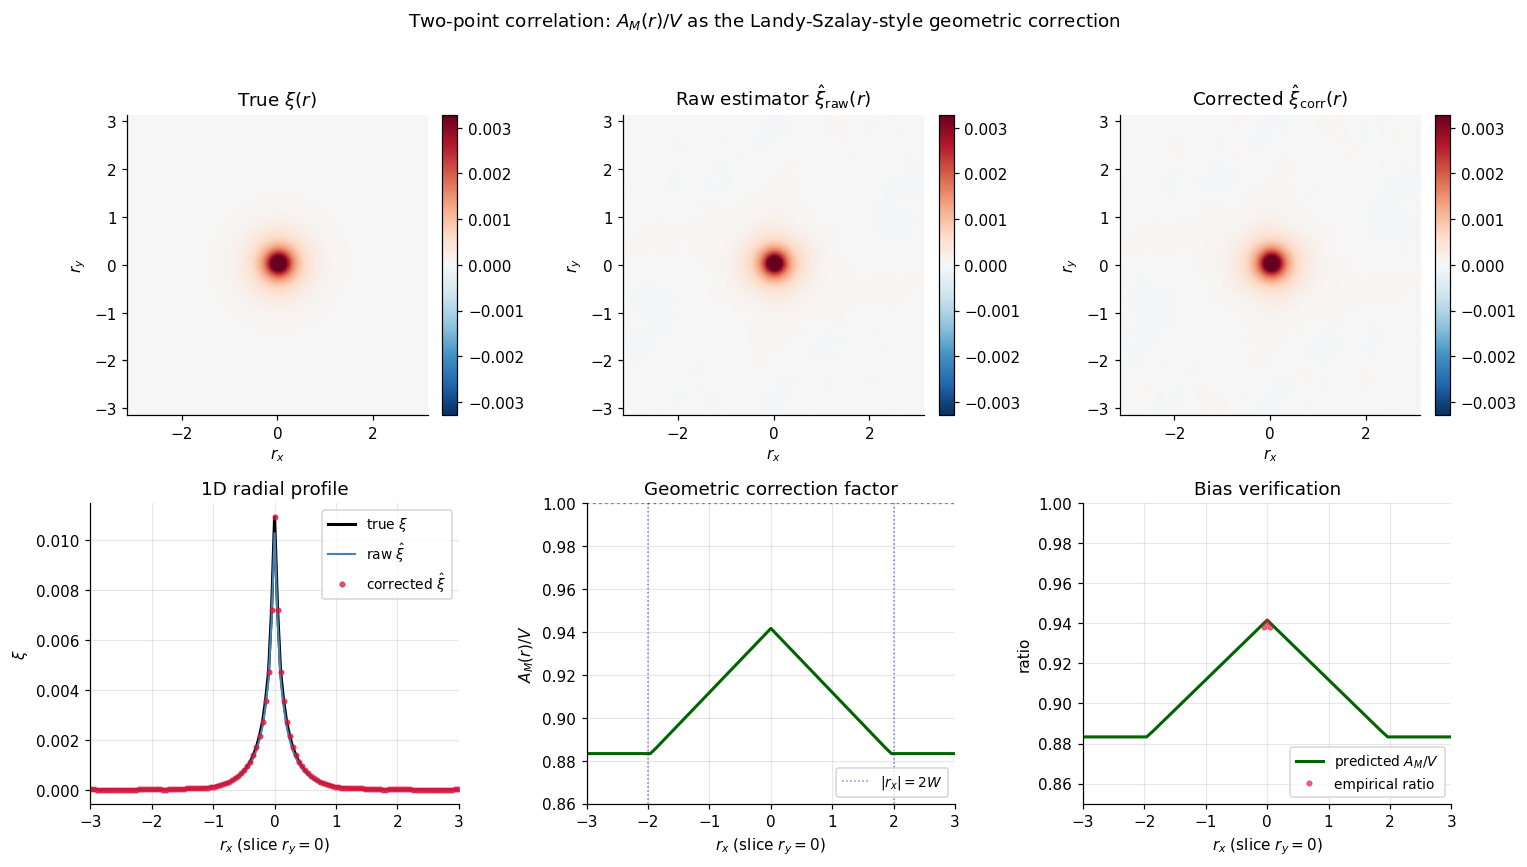

In [13]:
xi_true_c = np.fft.fftshift(xi_true)
mean_xi_raw_c = np.fft.fftshift(mean_xi_raw)
mean_xi_corrected_c = np.fft.fftshift(mean_xi_corrected)
A_M_normalized_c = np.fft.fftshift(A_M_normalized)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

vmax = xi_true_c.max() * 0.3

ax = axes[0, 0]
im = ax.imshow(xi_true_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'True $\xi(r)$')
ax.set_xlabel(r'$r_x$'); ax.set_ylabel(r'$r_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 1]
im = ax.imshow(mean_xi_raw_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'Raw estimator $\hat\xi_{\rm raw}(r)$')
ax.set_xlabel(r'$r_x$'); ax.set_ylabel(r'$r_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 2]
im = ax.imshow(mean_xi_corrected_c.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
ax.set_title(r'Corrected $\hat\xi_{\rm corr}(r)$')
ax.set_xlabel(r'$r_x$'); ax.set_ylabel(r'$r_y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

r_axis = np.fft.fftshift(np.fft.fftfreq(N, d=1) * L)
center_idx = N // 2

ax = axes[1, 0]
ax.plot(r_axis, xi_true_c[:, center_idx], color='black', linewidth=2,
        label=r'true $\xi$')
ax.plot(r_axis, mean_xi_raw_c[:, center_idx], color='steelblue', linewidth=1.4,
        label=r'raw $\hat\xi$')
ax.plot(r_axis, mean_xi_corrected_c[:, center_idx], 'o', color='crimson',
        markersize=3, alpha=0.7, label=r'corrected $\hat\xi$')
ax.set_xlim(-3, 3)
ax.set_xlabel(r'$r_x$ (slice $r_y = 0$)')
ax.set_ylabel(r'$\xi$')
ax.set_title('1D radial profile')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(r_axis, A_M_normalized_c[:, center_idx], color='darkgreen', linewidth=2)
ax.axhline(1.0, color='black', linestyle=':', alpha=0.5)
ax.axvline(2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1,
            label=r'$|r_x|=2W$')
ax.axvline(-2 * W_rect, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlim(-3, 3); ax.set_ylim(0.86, 1.0)
ax.set_xlabel(r'$r_x$ (slice $r_y = 0$)')
ax.set_ylabel(r'$A_M(r)/V$')
ax.set_title('Geometric correction factor')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 2]
ratio_emp = np.where(np.abs(xi_true_c[:, center_idx]) > 0.005,
                       mean_xi_raw_c[:, center_idx] / xi_true_c[:, center_idx],
                       np.nan)
ax.plot(r_axis, A_M_normalized_c[:, center_idx], color='darkgreen', linewidth=2,
        label=r'predicted $A_M/V$')
ax.plot(r_axis, ratio_emp, 'o', color='crimson', markersize=3, alpha=0.6,
        label='empirical ratio')
ax.set_xlim(-3, 3); ax.set_ylim(0.85, 1.0)
ax.set_xlabel(r'$r_x$ (slice $r_y = 0$)')
ax.set_ylabel('ratio')
ax.set_title('Bias verification')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Two-point correlation: $A_M(r)/V$ as the Landy-Szalay-style geometric correction',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## §7. Wiener inpainting — and the framework's lower bound

### What we're computing

Given $y(x) = M(x)\cdot(s(x) + n(x))$, produce an estimate $\hat s(x)$ of the underlying field across the entire domain. Optimal Bayesian estimator (Gaussian priors) is the *Wiener filter*. With masking, we use *POCS* (Projection Onto Convex Sets) — alternates Wiener filter (prior step) and re-pinning observed pixels (data fidelity step). Converges in 10-30 iterations.

### Framework's lower bound

At point $x_0$ inside the gap, $\beta(x_0) =$ fraction of a localized signal at $x_0$ that lives in the unmasked region. Reconstruction error variance lower bound: $\mathrm{Var}[s(x_0) - \hat s(x_0)] \geq (1 - \beta(x_0))\,\mathrm{Var}[s(x_0)]$.

For our setup: noise correlation length $1/k_c \approx 0.33$; gap interior depth max $\sim 0.5$. Deepest interior is borderline recoverable.

### Reading the figure

**Top row:** truth, observed, Wiener-inpainted reconstruction. 
**Bottom row:** error map (truth − inpainted, inside gap), distance map, error vs distance scatter.

In [14]:
def wiener_inpaint(y_observed, M_mask, S_signal_psd, S_noise_psd, n_iter=30):
    f = y_observed.copy()
    W_filter = S_signal_psd / (S_signal_psd + S_noise_psd)
    for k in range(n_iter):
        F = np.fft.fft2(f)
        f_filtered = np.real(np.fft.ifft2(F * W_filter))
        f = M_mask * y_observed + (1 - M_mask) * f_filtered
    return f


np.random.seed(0)
truth_field = generate_colored_noise()

sigma_meas = 0.05
S_meas_const = sigma_meas**2 * np.ones_like(S_n)
noise_meas = sigma_meas * np.random.standard_normal((N, N))
y_observed = M * (truth_field + noise_meas)

inpainted = wiener_inpaint(y_observed, M, S_signal_psd=S_n,
                            S_noise_psd=S_meas_const, n_iter=40)

error_field = truth_field - inpainted
err_rms_per_pixel = np.abs(error_field)
truth_rms = np.sqrt(np.mean(truth_field**2))
in_gap_mask = (1 - M).astype(bool)
print(f'Truth field RMS: {truth_rms:.4f}')
print(f'Mean abs error in gap: {err_rms_per_pixel[in_gap_mask].mean():.4f}')
print(f'Max abs error in gap: {err_rms_per_pixel[in_gap_mask].max():.4f}')

Truth field RMS: 0.1037
Mean abs error in gap: 0.0807
Max abs error in gap: 0.3219


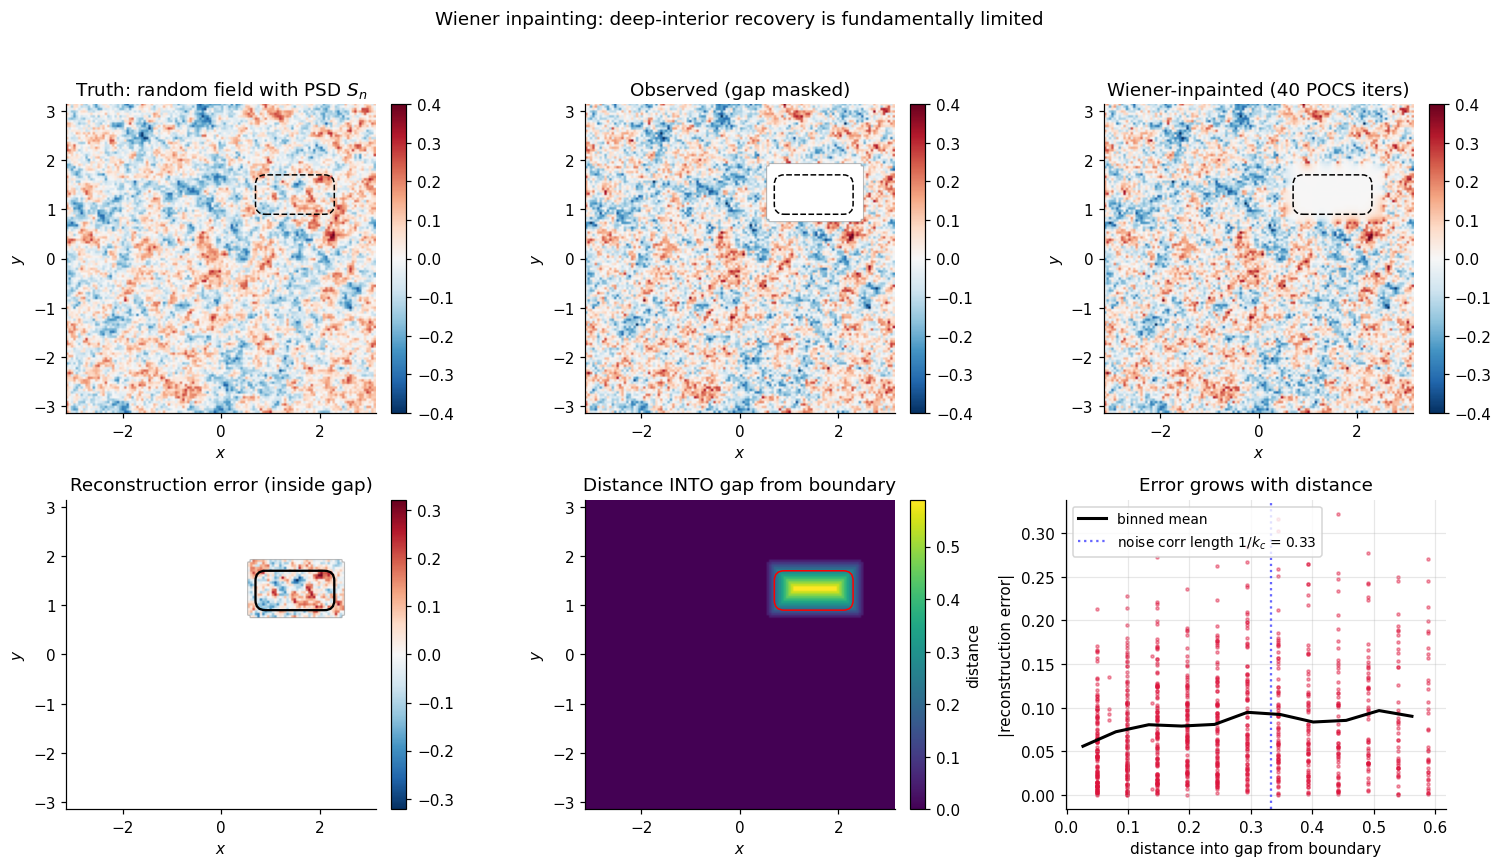

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

vmax = np.abs(truth_field).max() * 0.9

ax = axes[0, 0]
im = ax.imshow(truth_field.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='--', lw=1.0)
ax.set_title('Truth: random field with PSD $S_n$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 1]
y_observed_display = y_observed.copy()
y_observed_display[in_gap] = np.nan
im = ax.imshow(y_observed_display.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='--', lw=1.0)
ax.set_title('Observed (gap masked)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[0, 2]
im = ax.imshow(inpainted.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='--', lw=1.0)
ax.set_title('Wiener-inpainted (40 POCS iters)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

ax = axes[1, 0]
err_display = error_field.copy()
err_display[M.astype(bool)] = np.nan
err_vmax = np.nanmax(np.abs(err_display))
im = ax.imshow(err_display.T, cmap='RdBu_r', vmin=-err_vmax, vmax=err_vmax,
                origin='lower', extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='black', ls='-', lw=1.5)
ax.set_title('Reconstruction error (inside gap)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)

from scipy import ndimage
dist_from_edge = ndimage.distance_transform_edt(in_gap_mask) * dx

ax = axes[1, 1]
im = ax.imshow(dist_from_edge.T, cmap='viridis', origin='lower',
                extent=[-L/2, L/2, -L/2, L/2])
outline_rounded_rect(ax, W_rect, H_rect, r_corner, x_center, y_center,
                     color='red', ls='-', lw=1.0)
ax.set_title('Distance INTO gap from boundary')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label='distance')

ax = axes[1, 2]
in_gap_pix = in_gap_mask
ax.scatter(dist_from_edge[in_gap_pix], np.abs(error_field[in_gap_pix]),
            s=4, alpha=0.4, color='crimson')
bins = np.linspace(0, dist_from_edge[in_gap_pix].max(), 12)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_means = np.zeros(len(bin_centers))
for i in range(len(bin_centers)):
    sel = (dist_from_edge[in_gap_pix] >= bins[i]) & \
          (dist_from_edge[in_gap_pix] < bins[i+1])
    if sel.any():
        bin_means[i] = np.abs(error_field[in_gap_pix][sel]).mean()
    else:
        bin_means[i] = np.nan
ax.plot(bin_centers, bin_means, color='black', linewidth=2,
        label='binned mean')
ax.axvline(1/k_c, color='blue', linestyle=':', alpha=0.6,
            label=f'noise corr length $1/k_c$ = {1/k_c:.2f}')
ax.set_xlabel('distance into gap from boundary')
ax.set_ylabel('|reconstruction error|')
ax.set_title('Error grows with distance')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Wiener inpainting: deep-interior recovery is fundamentally limited',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## §8. Synthesis

One mask geometry — small, off-center, rounded rectangle — produces a distinct phantom signature in every downstream computation:

| Computation | Phantom signature | Mask object that controls it |
|---|---|---|
| Spectral matched filter (§2) | Rounded-rect FT envelope around *each* delta in spectrum | $\lvert\hat M(k)\rvert$ |
| Cross-correlation (§3) | Rounded-rect bump in 2D lag space, sized $2W\times 2H$ | $A_M(\Delta)$ |
| Detection (§4) | Phantom $\pm 3\sigma(\Delta)$ band; signal stripes punch through | $\sqrt{A_M(\Delta)}$ |
| PSD estimation (§5) | True PSD smeared by $\lvert\hat M\rvert^2$ | $\lvert\hat M(k)\rvert^2$ as smearing kernel |
| Two-point function (§6) | Multiplicative bias by $A_M(r)/V$ — Landy-Szalay correction | $A_M(r)/V$ |
| Wiener inpainting (§7) | Reconstruction error grows with distance into gap | Principal-angle suppression $1-\beta(x_0)$ |

### Why position vs shape matter differently

Translating the mask in space changes only the *phase* of $\hat M$, not its magnitude. So all spectral-domain phantoms (§2, §5) and lag-space phantoms based on autocorrelation (§3, §6) are exactly invariant under translation. Wiener inpainting (§7) is the exception — it cares about gap *position* because the *interior* of the gap (a position-dependent set) is geometrically where information is fundamentally lost.

### Why arbitrary multi-component signals don't change the framework

For multi-source signals — and the *wind-driven wave packet* in §§2 and 4 is an extreme example, with 6 distinct wave-vectors — each source mode contributes its *own* phantom envelope to the spectrum, its *own* stripe family to the cross-correlation. The phantoms add linearly because the framework operates linearly on signals. *The gap-induced shape of each phantom envelope is identical to the single-source case*, just centered at a different spectral location. So:

- A single coherent source: one envelope.
- A multi-source signal: one envelope per source.
- A *continuous-spectrum signal* (broadband noise, dispersive wave packet, line forest): one envelope per spectral peak, smearing into a continuous distribution if the peaks are dense.

The framework's predictions extend without modification to arbitrary signal complexity. Each spectral component of the source spectrum gets a copy of the gap's phantom envelope; the total observed spectrum is the convolution of the source spectrum with $|\hat M|$ (in amplitude) or $|\hat M|^2$ (in power). This is exactly the *pseudo-$C_\ell$ mode-coupling framework*, generalized.

### Why dispersive signals don't introduce new phantoms

The wind-driven wave packet's *temporal evolution* — long components outrunning short ones — is invisible to the spatial phantom analysis. The framework's predictions depend on the *spatial structure of the field at the observation moment*, full stop. Whether that field came from a coherent source, a dispersive packet, a stochastic process, or an unknown astrophysical population is irrelevant for predicting the phantom; only the *spatial spectrum at the observation time* matters. This is what makes the framework apply equally to:

- Static fields (CMB anisotropy, geological subsurface).
- Time-frozen snapshots of dispersive systems (wind waves, atmospheric turbulence).
- Single-frequency surveys of wide-band sources (radio interferometry on a fixed channel).
- Periodic phenomena observed in their phase-frozen frame (gravitational waves matched in template space).

### Why whitening doesn't fix any of this

Whitening is a *frequency-dependent rescaling* in Fourier space; it commutes with operations in Fourier space (multiplications) but not with operations in real space (multiplications by $M$). So phantom shapes survive the whitening pipeline; only their relative amplitudes change.

### What the framework gives you

For each computation, predicted phantom shape + amplitude + discrimination strategy + per-frequency/per-lag threshold calibration — all precomputable from the mask alone (or mask + noise model).